In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df=pd.read_csv('/content/sample_data/steam_games_preprocessed.csv')
df.head()

,release_year,price,recommendations,main_genre,developer_Archor Wright,developer_Blessing Company,developer_Boogygames Studios,developer_Bully Revenge Studios,developer_Creobit,developer_Cute Hannah's Games,...,Steam Turn Notifications,Steam Workshop,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported
0,2024,3.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,2025,7.99,0,Casual,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,2025,12.99,0,Adventure,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,2023,24.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,2021,3.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [50]:
num_bool_cols = df.select_dtypes(include=['number', 'bool']).columns

print(len(num_bool_cols))
print(num_bool_cols.tolist())

60
['release_year', 'price', 'recommendations', 'developer_Archor Wright', 'developer_Blessing Company', 'developer_Boogygames Studios', 'Adjustable Difficulty', 'Adjustable Text Size', 'Camera Comfort', 'Captions available', 'Chat Speech-to-text', 'Chat Text-to-speech', 'Co-op', 'Color Alternatives', 'Commentary available', 'Cross-Platform Multiplayer', 'Custom Volume Controls', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes level editor', 'Keyboard Only Option', 'LAN Co-op', 'LAN PvP', 'MMO', 'Mouse Only Option', 'Multi-player', 'Narrated Game Menus', 'Online Co-op', 'Online PvP', 'Partial Controller Support', 'Playable without Timed Input', 'PvP', 'Remote Play Together', 'Remote Play on Phone', 'Remote Play on TV', 'Remote Play on Tablet', 'Save Anytime', 'Shared/Split Screen', 'Shared/Split Screen Co-op', 'Shared/Split Screen PvP', 'Single-player', 'Stats', 'Steam Achievements', 'Steam Cloud', 'Steam Leaderboards',

In [41]:
len(df.columns)

79

In [53]:
df["main_genre"].nunique()

11

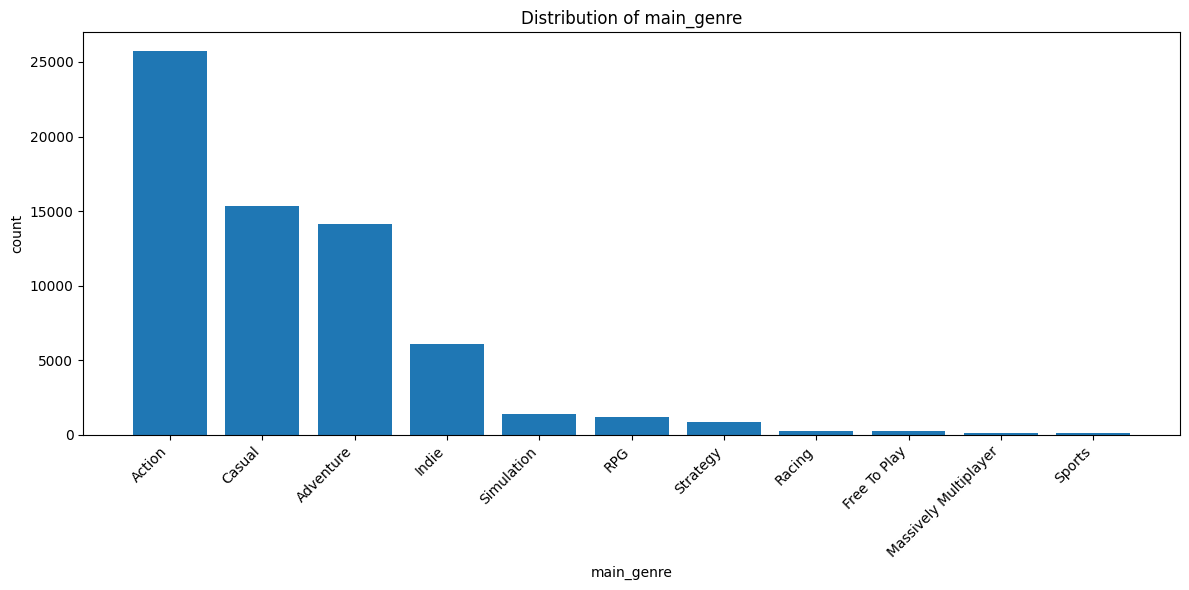

In [54]:
genre_counts = df["main_genre"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(genre_counts.index, genre_counts.values)

plt.xlabel("main_genre")
plt.ylabel("count")
plt.title("Distribution of main_genre")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 정답 컬럼
target_col = "main_genre"

# X, y 분리
X = df.drop(columns=[target_col])
y = df[target_col]

# y 문자열 라벨을 정수로 변환
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("클래스 개수:", len(label_encoder.classes_))
print("클래스 목록:", label_encoder.classes_)

클래스 개수: 11
클래스 목록: ['Action' 'Adventure' 'Casual' 'Free To Play' 'Indie'
 'Massively Multiplayer' 'RPG' 'Racing' 'Simulation' 'Sports' 'Strategy']


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [60]:
# 모델 학습 및 예측
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 정확도만 계산 및 출력
accuracy = accuracy_score(y_test, y_pred)
print(f"모델 정확도: {accuracy:.2%}")

모델 정확도: 43.71%


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 제약 조건은 다 빼고, 나무 개수만 100개(기본)에서 300개로 늘림
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"복구 및 강화된 모델 정확도: {accuracy:.2%}")

복구 및 강화된 모델 정확도: 43.96%


In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 불러오기
df = pd.read_csv('/content/sample_data/steam_games_preprocessed.csv')
target_col = "main_genre"

# 2. 안전한 수치형/불리언 컬럼만 먼저 선택 (문자열 노이즈 제거)
features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
if target_col in features:
    features.remove(target_col)

# 3. 과적합을 유발하는 고유 ID성 컬럼 자동 제거
# (값의 종류가 전체 데이터 개수의 90% 이상인 컬럼은 ID로 판단하여 제외)
valid_features = []
for col in features:
    if df[col].nunique() / len(df) < 0.9:
        valid_features.append(col)

X = df[valid_features]
y = df[target_col]

# 4. 정답(장르) 문자열을 숫자로 변환
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. 과적합 방지 설정을 더한 랜덤 포레스트 모델 학습
model = RandomForestClassifier(
    n_estimators=200,     # 나무 개수를 늘려 안정성 확보
    max_depth=20,         # 나무 깊이를 제한하여 고유 번호 암기 방지
    min_samples_split=5,  # 가지가 찢어지는 최소 조건 설정
    random_state=42,
    n_jobs=-1             # 코랩 CPU 풀가동 (속도 향상)
)
model.fit(X_train, y_train)

# 7. 정확도 확인
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"개선된 모델 정확도: {accuracy:.2%}")

개선된 모델 정확도: 46.33%


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. 방해물 걷어내기: 문자열 컬럼 제외
features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
if 'main_genre' in features:
    features.remove('main_genre')

# 2. 고유 ID(AppID 등) 자동 제거 (데이터가 너무 다양한 컬럼 버림)
valid_features = [col for col in features if df[col].nunique() / len(df) < 0.9]

# 3. 깨끗한 X 데이터와 정답 y 준비 (여기서 에러가 났었음!)
X_clean = df[valid_features]
y = df['main_genre']

# 4. 정답을 숫자로 변환하고 데이터 분리
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. 모델 학습 (나무 300개)
model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. 진짜 정확도 확인
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"데이터 정제 후 모델 정확도: {accuracy:.2%}")

데이터 정제 후 모델 정확도: 43.96%
